<a href="https://colab.research.google.com/github/WVF-1/Urban-Tree-Cover/blob/main/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — What Influences Urban Tree Cover?
## Part 2 of 3: Correlations, Feature Ranking & Clustering

**Building Data Together Data Science Newsletter**

Using the predictor table built in Notebook 1 (`week3_city_predictors.csv`), we explore how elevation, population density, land use, and open space relate to each city's tree census profile.

This is **purely exploratory** — no predictive model is trained or fit in this notebook. Everything here is descriptive statistics and unsupervised pattern-finding:

1. Correlation structure (Pearson + Spearman) between predictors and tree-cover outcomes
2. A correlation-based feature relevance ranking (not a model-based importance score)
3. K-means clustering of cities into "urban forest context" archetypes

A supervised model that actually *predicts* tree cover from these features is a natural next step — but that's Week 4's problem, not this one's.


## 0. Setup

In [1]:
!pip install -q scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", font_scale=1.05)

# Natural, tree-newsletter-consistent palette: greens & browns
NATURAL_PALETTE = ["#2E5339", "#6B8E4E", "#A9BA9D", "#C9A66B", "#8C6239", "#4A3728"]
sns.set_palette(NATURAL_PALETTE)
DIVERGING_CMAP = "BrBG"  # brown-green diverging, thematically on-point for a tree dataset


## 1. Load & prepare

In [3]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

CSV_NAME = "week3_city_predictors.csv"

if IN_COLAB:
    uploaded = files.upload()
    # The uploaded files are now accessible by their names in the /content/ directory.
    # CSV_NAME already points to the intended file, so no need to re-assign it here.

df = pd.read_csv(CSV_NAME)
print(df.shape)

PREDICTORS = [
    "elevation_m",
    "population_density_per_km2",
    "pct_impervious_proxy",
    "pct_parkland",
    "pct_water",
]
OUTCOMES = [
    "trees_per_km2",
    "trees_per_1000_pop",
    "ref_effective_species",
    "ref_percent_native",
]

analysis_cols = PREDICTORS + OUTCOMES
n_before = len(df)
df_clean = df.dropna(subset=analysis_cols).copy()
n_after = len(df_clean)

print(f"Dropped {n_before - n_after} of {n_before} cities with missing values in analysis columns")
print(f"Analyzing {n_after} cities")

df_clean[analysis_cols].describe().T

Saving week3_city_boundaries.geojson to week3_city_boundaries (1).geojson
Saving week3_city_predictors.csv to week3_city_predictors (1).csv
(63, 21)
Dropped 51 of 63 cities with missing values in analysis columns
Analyzing 12 cities


,count,mean,std,min,25%,50%,75%,max
elevation_m,12.0,544.083333,704.887413,4.000000,52.750000,217.000000,676.500000,1839.000000
population_density_per_km2,12.0,1574.029828,745.621307,540.921825,1021.644924,1422.342418,2254.425923,2625.225373
pct_impervious_proxy,12.0,0.425850,0.164546,0.137253,0.382165,0.430567,0.539733,0.694056
pct_parkland,12.0,0.054616,0.024857,0.017421,0.036690,0.048264,0.069819,0.101283
pct_water,12.0,0.044566,0.045955,0.005395,0.011930,0.027532,0.054443,0.140141
trees_per_km2,12.0,304.159649,346.017827,4.886074,55.601848,127.741061,533.285229,1096.480457
trees_per_1000_pop,12.0,181.453037,168.492943,2.063576,53.205140,175.725243,212.785124,513.575508
ref_effective_species,12.0,35.407054,13.219809,19.549491,23.639626,32.680080,47.941863,57.090891
ref_percent_native,12.0,0.445108,0.315967,0.016012,0.212344,0.433295,0.750941,0.854560


## 2. Correlation structure

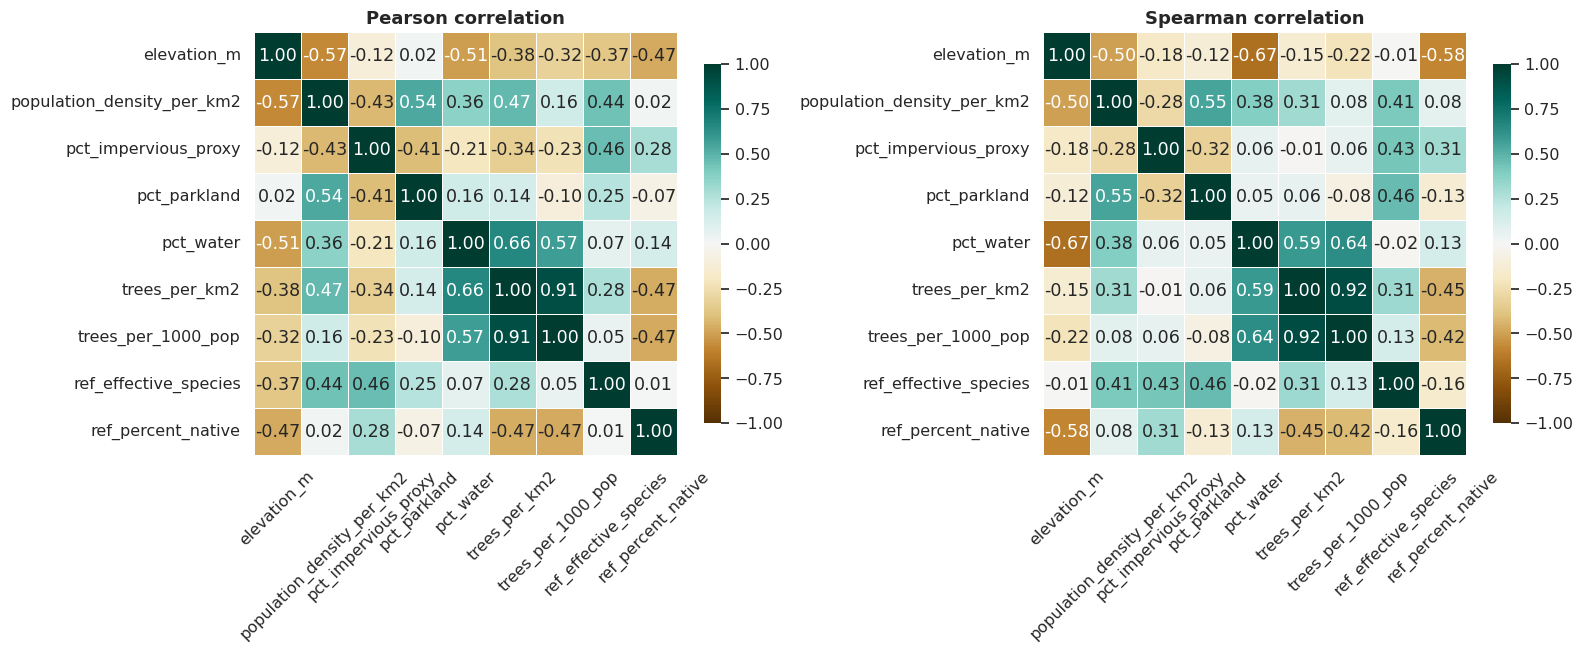

In [4]:
pearson_corr = df_clean[analysis_cols].corr(method="pearson")
spearman_corr = df_clean[analysis_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, corr, title in zip(axes, [pearson_corr, spearman_corr], ["Pearson", "Spearman"]):
    sns.heatmap(
        corr, ax=ax, cmap=DIVERGING_CMAP, vmin=-1, vmax=1, center=0,
        annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.8},
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(f"{title} correlation", fontsize=13, fontweight="bold")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("week3_correlation_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Correlation-based feature relevance ranking

For each outcome variable, rank predictors by absolute Pearson correlation. This is explicitly a *bivariate, correlation-based* ranking, not a fitted model's feature-importance score — no model is trained here.

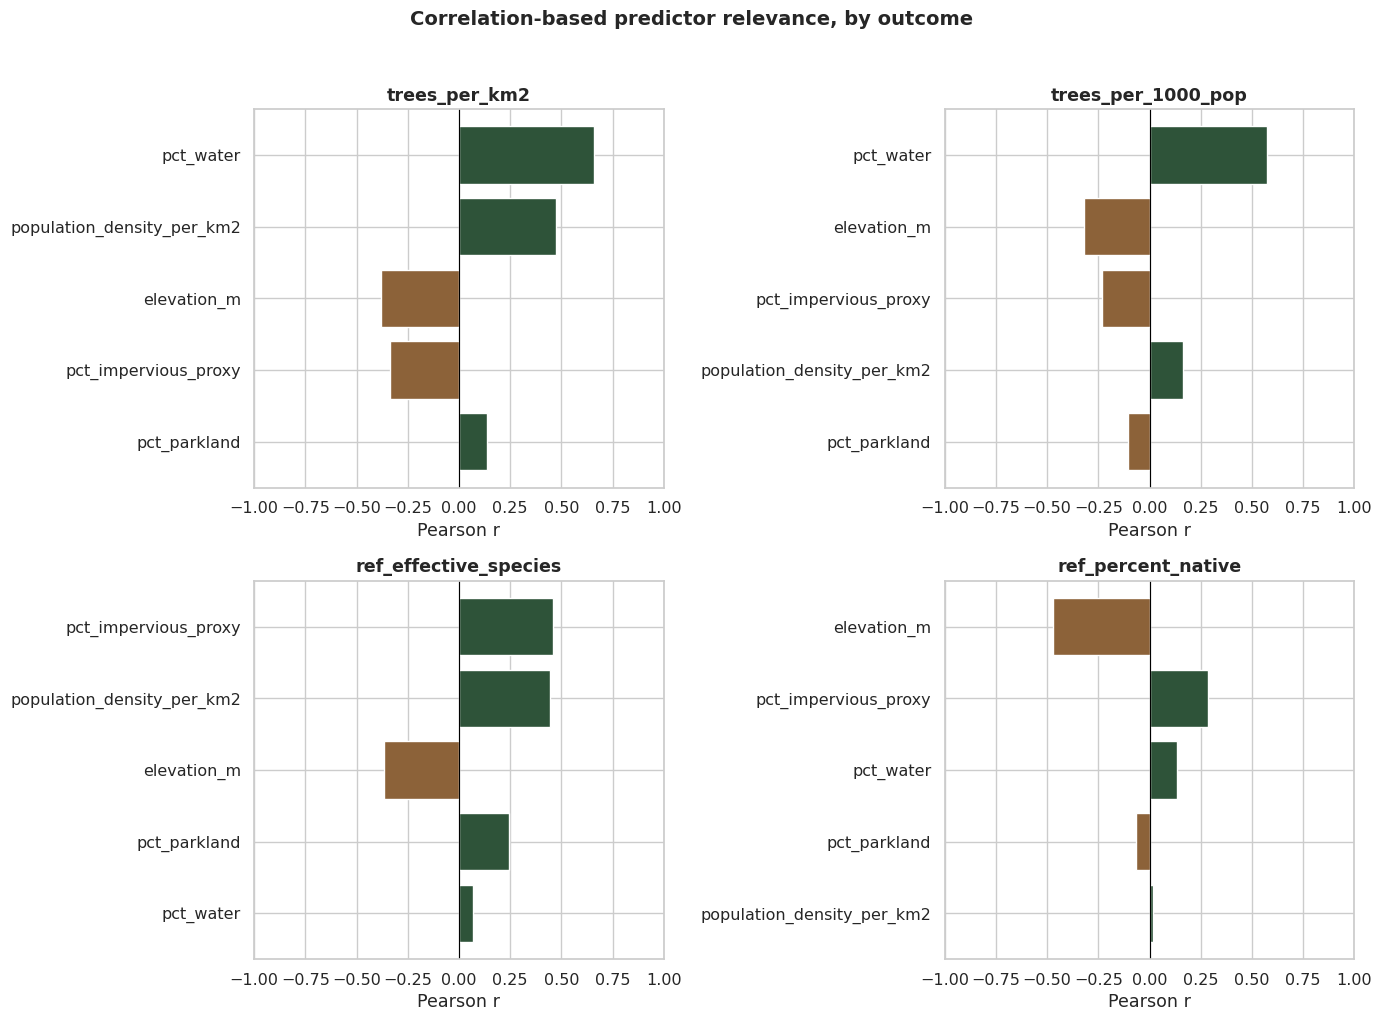

outcome,ref_effective_species,ref_percent_native,trees_per_1000_pop,trees_per_km2
predictor,,,,
elevation_m,-0.37,-0.47,-0.32,-0.38
pct_impervious_proxy,0.46,0.28,-0.23,-0.34
pct_parkland,0.25,-0.07,-0.10,0.14
pct_water,0.07,0.14,0.57,0.66
population_density_per_km2,0.44,0.02,0.16,0.47


In [5]:
rank_rows = []
for outcome in OUTCOMES:
    for pred in PREDICTORS:
        r, p = stats.pearsonr(df_clean[pred], df_clean[outcome])
        rank_rows.append({
            "outcome": outcome, "predictor": pred,
            "pearson_r": r, "abs_r": abs(r), "p_value": p,
        })

rank_df = pd.DataFrame(rank_rows).sort_values(["outcome", "abs_r"], ascending=[True, False])

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
for ax, outcome in zip(axes.flat, OUTCOMES):
    sub = rank_df[rank_df["outcome"] == outcome].sort_values("abs_r")
    colors = [NATURAL_PALETTE[0] if r > 0 else NATURAL_PALETTE[4] for r in sub["pearson_r"]]
    ax.barh(sub["predictor"], sub["pearson_r"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(outcome, fontweight="bold")
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Pearson r")

plt.suptitle("Correlation-based predictor relevance, by outcome", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("week3_feature_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

rank_df.pivot(index="predictor", columns="outcome", values="pearson_r").round(2)


## 4. Relationship scatterplots

Visualizing the strongest bivariate relationships found above. Trend lines are simple OLS fits for visual reference only — this is a descriptive plot, not a predictive model.

              outcome                  predictor  pearson_r  p_value
        trees_per_km2                  pct_water   0.659870 0.019546
   trees_per_1000_pop                  pct_water   0.571458 0.052255
        trees_per_km2 population_density_per_km2   0.473591 0.119891
   ref_percent_native                elevation_m  -0.469542 0.123534
ref_effective_species       pct_impervious_proxy   0.458008 0.134309
ref_effective_species population_density_per_km2   0.444205 0.147980


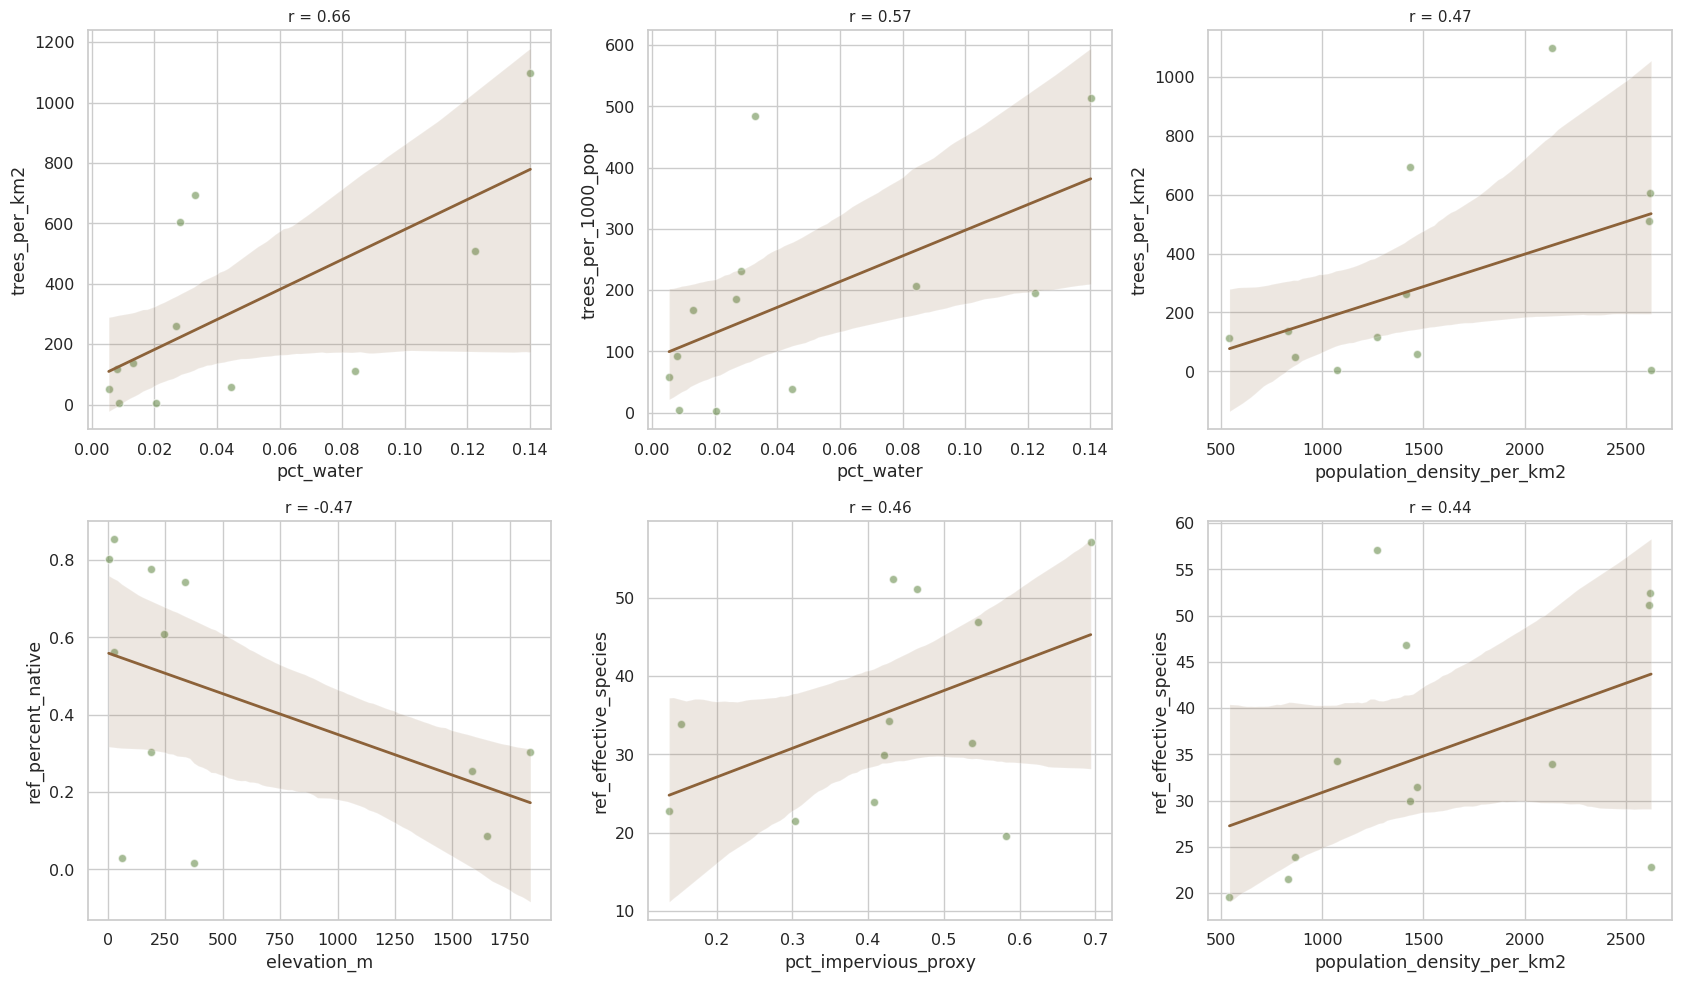

In [6]:
top_pairs = rank_df.sort_values("abs_r", ascending=False).head(6)
print(top_pairs[["outcome", "predictor", "pearson_r", "p_value"]].to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    sns.regplot(
        data=df_clean, x=row["predictor"], y=row["outcome"], ax=ax,
        scatter_kws={"alpha": 0.6, "color": NATURAL_PALETTE[1], "edgecolor": "white"},
        line_kws={"color": NATURAL_PALETTE[4], "linewidth": 2},
    )
    ax.set_title(f"r = {row['pearson_r']:.2f}", fontsize=11)

plt.tight_layout()
plt.savefig("week3_top_relationships.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Clustering: urban forest context archetypes

We standardize the five predictor variables and use K-means to group cities into archetypal "urban forest contexts" — e.g. a dense, impervious-heavy cluster vs. a low-density, park-rich cluster. This is unsupervised pattern discovery over the *predictors only*; the outcome variables aren't used to form the clusters, so we can honestly ask afterward whether the clusters differ in their tree-cover profile.


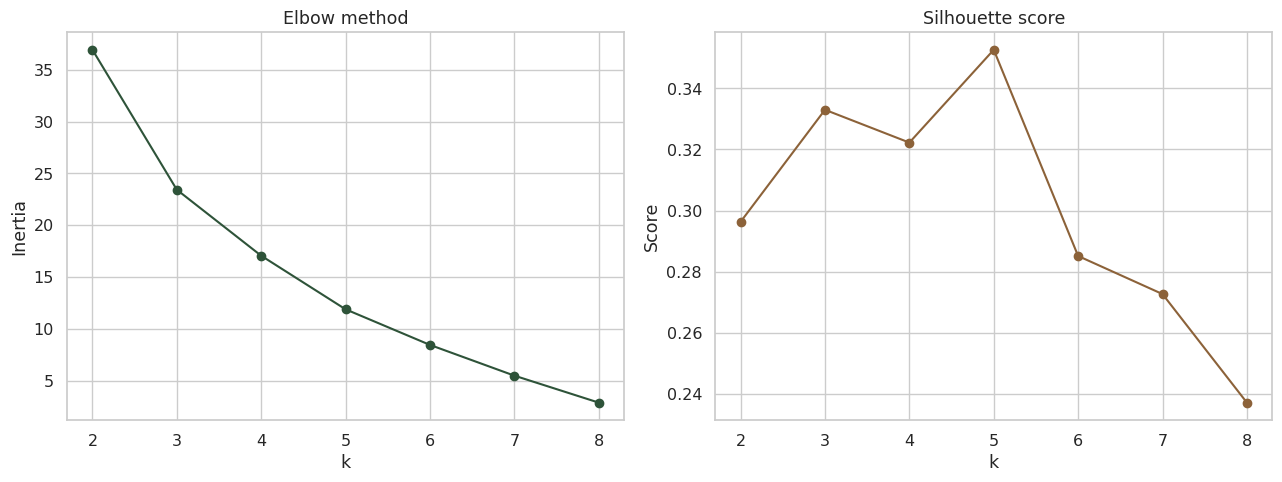

Best k by silhouette score: 5 (you can override this manually below)


In [7]:
X = df_clean[PREDICTORS].values
X_scaled = StandardScaler().fit_transform(X)

k_range = range(2, 9)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o", color=NATURAL_PALETTE[0])
axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color=NATURAL_PALETTE[4])
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout()
plt.savefig("week3_cluster_selection.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k} (you can override this manually below)")


Explained variance (PC1, PC2): [0.46 0.28]


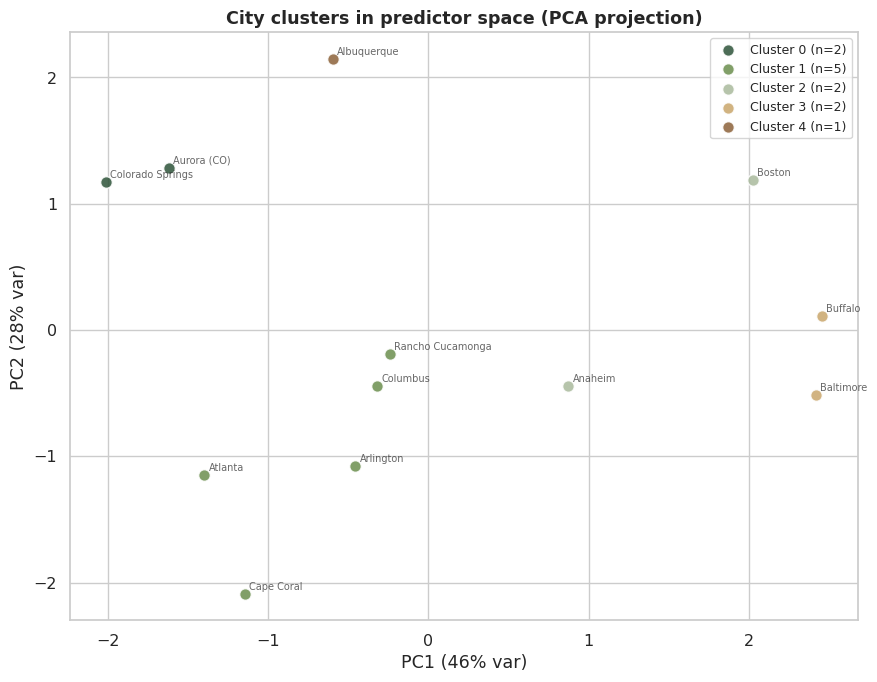

In [8]:
# Set K explicitly once you've eyeballed the elbow/silhouette plots above.
K = best_k

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_clean["pca1"], df_clean["pca2"] = coords[:, 0], coords[:, 1]

print(f"Explained variance (PC1, PC2): {pca.explained_variance_ratio_.round(2)}")

fig, ax = plt.subplots(figsize=(9, 7))
for cluster_id in sorted(df_clean["cluster"].unique()):
    sub = df_clean[df_clean["cluster"] == cluster_id]
    ax.scatter(sub["pca1"], sub["pca2"], s=70, alpha=0.85,
               color=NATURAL_PALETTE[cluster_id % len(NATURAL_PALETTE)],
               label=f"Cluster {cluster_id} (n={len(sub)})", edgecolor="white")
for _, row in df_clean.iterrows():
    ax.annotate(row["city"], (row["pca1"], row["pca2"]), fontsize=7, alpha=0.7,
                xytext=(3, 3), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
ax.set_title("City clusters in predictor space (PCA projection)", fontweight="bold")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("week3_cluster_pca.png", dpi=150, bbox_inches="tight")
plt.show()


### Cluster profiles: predictors and tree-cover outcomes

In [9]:
profile = df_clean.groupby("cluster")[PREDICTORS + OUTCOMES].mean().round(2)
profile["n_cities"] = df_clean.groupby("cluster").size()
profile


,elevation_m,population_density_per_km2,pct_impervious_proxy,pct_parkland,pct_water,trees_per_km2,trees_per_1000_pop,ref_effective_species,ref_percent_native,n_cities
cluster,,,,,,,,,,
0,1745.5,847.58,0.36,0.04,0.01,94.19,112.33,22.73,0.19,2
1,229.4,1225.35,0.56,0.04,0.04,248.09,201.35,36.98,0.59,5
2,44.0,2622.64,0.29,0.06,0.02,305.15,116.46,37.59,0.44,2
3,108.0,2373.86,0.31,0.08,0.13,802.95,354.28,42.52,0.43,2
4,1587.0,1073.46,0.43,0.10,0.01,4.89,4.55,34.31,0.25,1


In [10]:
example_cities = df_clean.groupby("cluster")["city"].apply(lambda s: ", ".join(s.head(5)))
for cluster_id, cities in example_cities.items():
    print(f"Cluster {cluster_id}: {cities}")


Cluster 0: Aurora (CO), Colorado Springs
Cluster 1: Arlington, Atlanta, Cape Coral, Columbus, Rancho Cucamonga
Cluster 2: Anaheim, Boston
Cluster 3: Baltimore, Buffalo
Cluster 4: Albuquerque


## 6. Export for mapping (Notebook 3)

In [11]:
OUT_CSV = "week3_city_predictors_clustered.csv"
df_clean.to_csv(OUT_CSV, index=False)
print(f"Saved {OUT_CSV}")

if IN_COLAB:
    files.download(OUT_CSV)


Saved week3_city_predictors_clustered.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Takeaways to write up

*(Fill in after running against the real merged data — leaving this as a template.)*

- Which predictor had the strongest correlation with tree density / diversity, and in which direction?
- Did any relationship surprise you relative to the Week 1–2 findings?
- What do the cluster archetypes look like in plain language — is there a "sprawling and green" cluster vs. a "dense and paved" one?
- Where are the honest limits of this analysis (small n=63, correlation ≠ causation, proxy variables from Notebook 1)?

Notebook 3 puts these clusters and variables on a map to see whether the patterns have any obvious regional structure.
